# 📈 모델 비교 실험: 로지스틱 회귀 vs 랜덤 포레스트 vs XGBoost

이 노트북은 `data/processed/selected_features_data.csv`를 활용하여 세 가지 다른 머신러닝 모델의 성능을 비교 분석합니다.

### 🧪 실험 설정
- **데이터 분할:** Train(70%) / Val(15%) / Test(15%) (시계열 순서 유지)
- **평가 지표:** Accuracy, Precision, Recall, F1-Score, ROC-AUC
- **모델:** Logistic Regression, Random Forest, XGBoost

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

## 1. 데이터 로드 및 시계열 분할 (70/15/15)

In [28]:
# 데이터 로드
DATA_PATH = "../data/processed/selected_features_data.csv"
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# 피처 및 타겟 분리
exclude = ['Date', 'ticker', 'target', 'next_return']
features = [c for c in df.columns if c not in exclude]
X = df[features]
y = df['target']

# 70 / 15 / 15 분할 인덱스 계산
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print(f"Total samples: {n}")
print(f"Train samples: {len(X_train)} ({len(X_train)/n:.1%})")
print(f"Val samples: {len(X_val)} ({len(X_val)/n:.1%})")
print(f"Test samples: {len(X_test)} ({len(X_test)/n:.1%})")

Total samples: 1464
Train samples: 1024 (69.9%)
Val samples: 220 (15.0%)
Test samples: 220 (15.0%)


## 2. 모델 학습 및 평가 함수 정의

In [29]:
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, name):
    model.fit(X_train, y_train)
    
    sets = [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]
    results = []
    
    print(f"\n=== {name} Performance ===")
    for set_name, X_set, y_set in sets:
        preds = model.predict(X_set)
        probs = model.predict_proba(X_set)[:, 1]
        
        acc = accuracy_score(y_set, preds)
        pre = precision_score(y_set, preds)
        rec = recall_score(y_set, preds)
        f1 = f1_score(y_set, preds)
        auc = roc_auc_score(y_set, probs)
        
        results.append({
            'Model': name,
            'Set': set_name,
            'Accuracy': acc,
            'Precision': pre,
            'Recall': rec,
            'F1': f1,
            'AUC': auc
        })
        print(f"[{set_name}] Acc: {acc:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    return results

## 3. 최적 파라미터 적용 및 학습

각 실험용 노트북(`{model}_lab.ipynb`)에서 다시 획득한 최적의 정규화 파라미터를 적용합니다.

In [30]:
# 1) Logistic Regression (Best: ElasticNet, C=0.001, balanced)
lr_model = LogisticRegression(
    C=0.001, 
    class_weight='balanced', 
    l1_ratio=0.5, 
    penalty='elasticnet', 
    solver='saga', 
    max_iter=10000, 
    random_state=42
)

# 2) Random Forest (Best: max_depth=3, min_samples_leaf=10)
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=3, 
    min_samples_leaf=10, 
    min_samples_split=20, 
    max_features='sqrt', 
    random_state=42
)

# 3) XGBoost (Best: learning_rate=0.01, max_depth=2, reg_alpha=1)
xgb_model = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.01, 
    max_depth=2, 
    subsample=0.7, 
    colsample_bytree=0.7, 
    reg_alpha=1, 
    reg_lambda=1, 
    eval_metric='logloss', 
    random_state=42
)

all_results = []
all_results.extend(evaluate_model(lr_model, X_train, y_train, X_val, y_val, X_test, y_test, "Logistic Regression"))
all_results.extend(evaluate_model(rf_model, X_train, y_train, X_val, y_val, X_test, y_test, "Random Forest"))
all_results.extend(evaluate_model(xgb_model, X_train, y_train, X_val, y_val, X_test, y_test, "XGBoost"))


=== Logistic Regression Performance ===
[Train] Acc: 0.5381, F1: 0.6997, AUC: 0.5000
[Val] Acc: 0.5182, F1: 0.6826, AUC: 0.5000
[Test] Acc: 0.5182, F1: 0.6826, AUC: 0.5000

=== Random Forest Performance ===
[Train] Acc: 0.6367, F1: 0.7373, AUC: 0.7539
[Val] Acc: 0.5455, F1: 0.6241, AUC: 0.5130
[Test] Acc: 0.5227, F1: 0.5817, AUC: 0.4972

=== XGBoost Performance ===
[Train] Acc: 0.6348, F1: 0.7370, AUC: 0.7364
[Val] Acc: 0.5045, F1: 0.5918, AUC: 0.5237
[Test] Acc: 0.5000, F1: 0.5865, AUC: 0.4728


## 4. 최종 결과 비교 및 혼동 행렬 시각화


--- [Final Test Set Comparison (Optimized Models)] ---


,Set,Accuracy,Precision,Recall,F1,AUC
Model,,,,,,
Logistic Regression,Test,0.518182,0.518182,1.000000,0.682635,0.500000
Random Forest,Test,0.522727,0.532847,0.640351,0.581673,0.497186
XGBoost,Test,0.500000,0.513158,0.684211,0.586466,0.472774


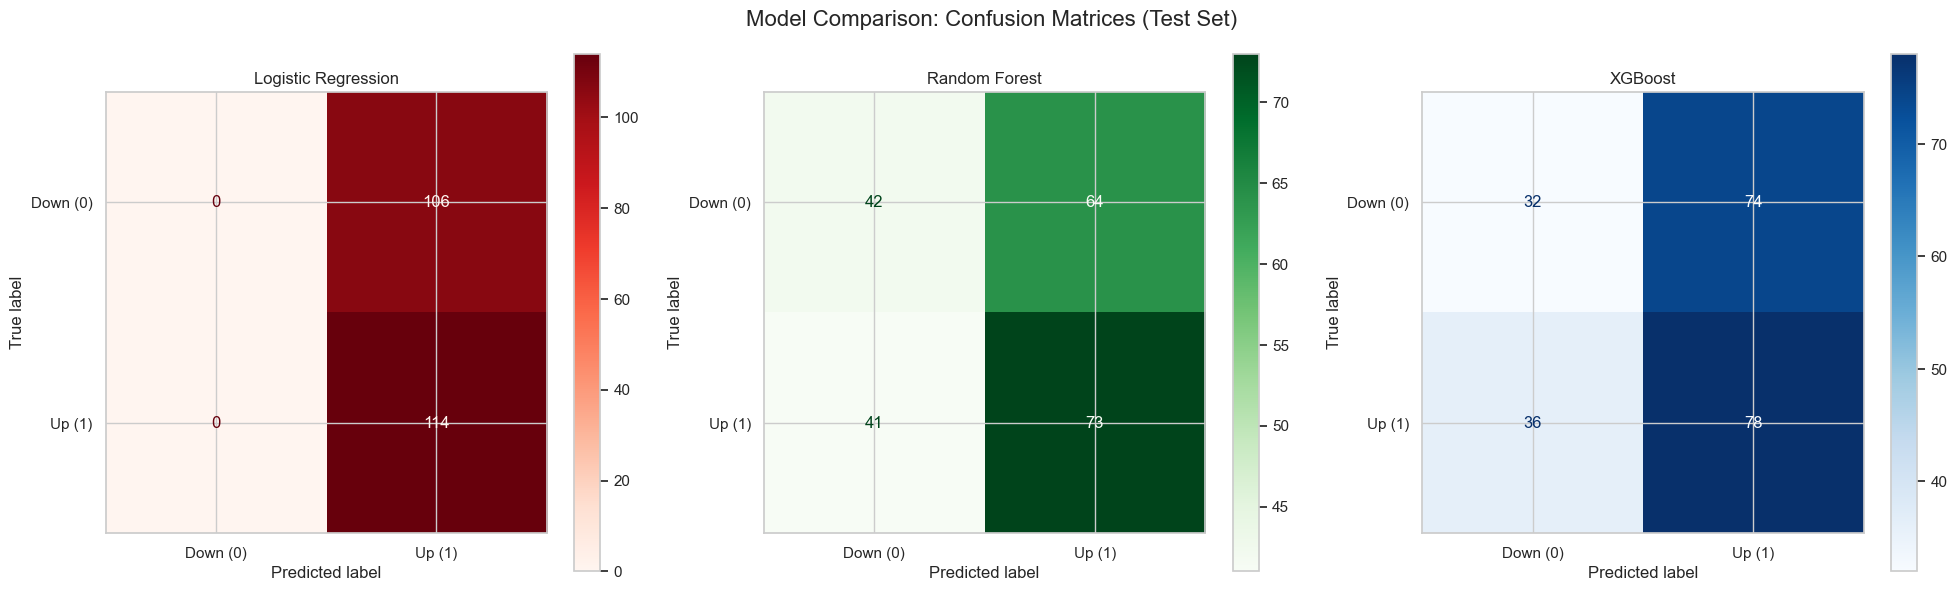

In [31]:
results_df = pd.DataFrame(all_results)
test_results = results_df[results_df['Set'] == 'Test'].set_index('Model')

print("\n--- [Final Test Set Comparison (Optimized Models)] ---")
display(test_results)

# 혼동 행렬 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models_to_plot = [
    (lr_model, "Logistic Regression", 'Reds'),
    (rf_model, "Random Forest", 'Greens'),
    (xgb_model, "XGBoost", 'Blues')
]

for ax, (model, name, cmap) in zip(axes, models_to_plot):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down (0)', 'Up (1)'])
    disp.plot(ax=ax, cmap=cmap, values_format='d')
    ax.set_title(f"{name}")

plt.suptitle("Model Comparison: Confusion Matrices (Test Set)", fontsize=16)
plt.tight_layout()
plt.show()